In [1]:
import os, math, shutil, threading
from concurrent.futures import ThreadPoolExecutor, as_completed

import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from skimage.feature import hog
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
import joblib
from tqdm import tqdm
from face_detection import DNNFaceDetector

# Local modules
from preprocessing   import (face_to_gray, convert_crops_to_gray, extract_hog_batch,
                              flatten_images, normalize_per_image, apply_pca,
                              get_train_val_split, summarize_dataset, save_crops)
from visualize       import (plot_class_distribution, plot_class_grid, plot_face_debug,
                              plot_image_sequence, plot_hog_features, plot_tsne,
                              plot_eigenfaces, plot_explained_variance,
                              plot_pca_reconstruction, plot_pca_scatter,
                              plot_validation_images, plot_confusion_matrix)
from annotate import FaceAnnotator, load_data, run_multi_annotation
import random
from urllib import request
from scipy.spatial.distance import cosine, euclidean


In [2]:
# Global constants used throughout the notebook
DATASET_FOLDER = "datasets/train/"  # Where the original .npy files are
ANNOTATIONS_CSV = "annotations.csv"
FACE_SIZE   = (160, 160)
TARGET_SIZE = (64, 64)     # HOG/PCA input size
CLASS_NAMES = {
    0: "Michael_Cera",
    1: "Jesse_Eisenberg",
    2: "Mila_Kunis",
    3: "Sarah_Hyland",
    4: "Not_A_Face"
}
CLASS_COLOURS = {
    0: "blue",     
    1: "orange",  
    2: "green",  
    3: "red",      
    4: "purple"    
}

os.makedirs("final_train_extracted_faces", exist_ok=True)
os.makedirs('final_data', exist_ok=True)
face_detector = DNNFaceDetector(path="models", face_size=FACE_SIZE)

In [3]:
train = pd.read_csv('datasets/train_set.csv', index_col=0)
train.index = train.index.rename('id')

test = pd.read_csv('datasets/test_set.csv', index_col=0)
test.index = test.index.rename('id')

# Load raw images as RGB numpy arrays
train['img'] = [cv2.cvtColor(np.load(f'datasets/train/train_{i}.npy', allow_pickle=False),
                              cv2.COLOR_BGR2RGB) for i, _ in train.iterrows()]
test['img']  = [cv2.cvtColor(np.load(f'datasets/test/test_{i}.npy',  allow_pickle=False),
                              cv2.COLOR_BGR2RGB) for i, _ in test.iterrows()]

print(f"Training set : {len(train)} images")
print(f"Test set     : {len(test)}  images")

Training set : 80 images
Test set     : 1816  images


In [4]:
label_to_int = {v: k for k, v in CLASS_NAMES.items()}

# --- 2. Load the Data ---
df = pd.read_csv(ANNOTATIONS_CSV)

original_images = []
extracted_faces = []
labels = []

for _, row in df.iterrows():
    orig_file = row['original_file']     
    crop_path = row['saved_crop_path']
    label_str = row['manual_label']

    orig_path = os.path.join(DATASET_FOLDER, orig_file)

    # Only load if both the original file and your new crop exist
    if os.path.exists(orig_path) and pd.notna(crop_path) and os.path.exists(crop_path):
        
        # Load Original Image (.npy is BGR, convert to RGB)
        img_bgr = np.load(orig_path, allow_pickle=False)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        original_images.append(img_rgb)

        # Load Extracted Crop (.jpg is BGR, convert to RGB)
        crop_bgr = cv2.imread(crop_path)
        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
        extracted_faces.append(crop_rgb)

        # Convert label back to integer (e.g., "Mila_Kunis" -> 2)
        labels.append(label_to_int[label_str])

# --- 3. Format Variables for visualize.py ---
# plot_face_debug expects a DataFrame with an 'img' column for the originals
train = pd.DataFrame({'img': original_images})
X_train_final = np.array(extracted_faces)
y_train_final = np.array(labels)

print(f"Successfully loaded {len(X_train_final)} annotated samples.")

Successfully loaded 102 annotated samples.


In [6]:
test_X = test['img']
test_images = []
for img in test_X:
    # Convert individual element to a numpy array
    img_arr = np.array(img, dtype=np.uint8)
    
    # Safety check: If any image is grayscale (2 dimensions instead of 3), convert it to RGB
    if len(img_arr.shape) == 2:
        img_arr = cv2.cvtColor(img_arr, cv2.COLOR_GRAY2RGB)
        
    # 3. Resize the image to exactly 160x160
    resized_img = cv2.resize(img_arr, FACE_SIZE)
    
    # Add to our new, clean list
    test_images.append(resized_img)
test_X_final = np.array(test_images)

In [7]:
def _to_display(img: np.ndarray) -> np.ndarray:
    """
    Converts any face-crop array to a uint8 RGB image suitable for imshow.

    Handles:
      - float32 in [0, 255]  → divide by 255, clamp, uint8
      - float32 in [0, 1]    → clamp, uint8
      - uint8                → pass through
    """
    if img.dtype == np.uint8:
        return img
    if img.max() > 1.5:  # [0, 255] float range
        return np.clip(img / 255.0, 0, 1)
    return np.clip(img, 0, 1)  # already [0, 1]


def _is_nan_face(img: np.ndarray) -> bool:
    """Returns True for sentinel NaN arrays produced by failed detection."""
    return np.isnan(img).any()

def plot_face_debug(
    data,
    face_array: np.ndarray,
    label_array: np.ndarray = None,
    class_id: int = None,
    n: int = 10,
    class_names: dict = None,
    pairs_per_row: int = 3,  # NEW: Controls how many pairs are shown horizontally
) -> None:
    """
    Shows each original image next to its extracted face crop.
    Works for both labeled training data and unlabeled test data.
    """
    # 1. Determine which indices to plot
    if label_array is not None and class_id is not None:
        # Labeled mode: filter by class
        # (Assuming _resolve_class_names handles None appropriately, fallback used just in case)
        if class_names is None:
            class_names = {}
        indices = np.where(label_array == class_id)[0]
        suptitle = f"Class {class_id} — {class_names.get(class_id, class_id)}"
    else:
        # Unlabeled/Test mode: just take the first n samples
        indices = np.arange(len(face_array))
        suptitle = "Unlabeled / Test Data Samples"

    # 2. Limit n to available data
    n = min(n, len(indices))
    if n == 0:
        print("No samples found to plot.")
        return

    # 3. Create grid layout
    num_rows = math.ceil(n / pairs_per_row)
    actual_cols = min(n, pairs_per_row) * 2  # 2 columns per pair (Original + Crop)

    # Adjust figsize to keep images square but tile them horizontally
    fig, axes = plt.subplots(
        num_rows, actual_cols, figsize=(2.5 * actual_cols, 3 * num_rows)
    )

    # Flatten axes array for easier linear iteration
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    fig.suptitle(f"{suptitle} ({n} samples)", fontsize=14, y=1.02)

    # Hide all axes initially (useful for empty subplots in the last row)
    for ax in axes:
        ax.axis("off")

    # 4. Plot images
    for i, idx in enumerate(indices[:n]):
        # Calculate the 1D index for the left (original) and right (face) subplots
        orig_idx = 2 * i
        face_idx = 2 * i + 1

        # Left: original image from the DataFrame
        orig = data.iloc[idx]["img"]
        axes[orig_idx].imshow(_to_display(orig.astype(np.float32)))
        axes[orig_idx].set_title(f"Orig #{idx}", fontsize=9)

        # Right: extracted face crop from the array
        face = face_array[idx]
        if _is_nan_face(face):
            axes[face_idx].text(
                0.5, 0.5, "No face", ha="center", va="center", color="red"
            )
            axes[face_idx].set_title("Detection Failed", fontsize=9, color="red")
        else:
            axes[face_idx].imshow(_to_display(face))
            axes[face_idx].set_title("Extracted", fontsize=9, color="green")

    plt.tight_layout()
    plt.show()

In [8]:
def augment(images, labels, num_variants=2):
    """
    Creates exactly (1 + num_variants) images per original image.
    Uses randomized combinations of mirroring, lighting, geometric shifts,
    and Cutout (Random Erasing) so the dataset doesn't explode in size.
    """
    aug_X, aug_y = [], []
    
    # Ensure images is not empty before grabbing shape
    if len(images) == 0:
        return np.array([]), np.array([])
        
    h, w = images[0].shape[:2]
    center = (w // 2, h // 2)

    # Setup CLAHE
    clahe_obj = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    for img, label in zip(images, labels):
        # 1. Always keep the clean original
        aug_X.append(img)
        aug_y.append(label)

        # 2. Generate exactly 'num_variants' additional augmented copies
        for _ in range(num_variants):
            aug_img = img.copy()

            # --- A. Random Mirror (50% chance) ---
            if random.choice([True, False]):
                aug_img = cv2.flip(aug_img, 1)

            # --- B. Random Lighting (Choose one: CLAHE, Dark, Light, or None) ---
            light_choice = random.choice(["clahe", "dark", "light", "none"])
            
            aug_img_uint8 = np.clip(aug_img, 0, 255).astype(np.uint8)
            
            if light_choice == "clahe":
                if len(aug_img_uint8.shape) == 3:
                    lab = cv2.cvtColor(aug_img_uint8, cv2.COLOR_RGB2LAB)
                    l, a, b = cv2.split(lab)
                    cl = clahe_obj.apply(l)
                    limg = cv2.merge((cl, a, b))
                    aug_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
                else:
                    aug_img = clahe_obj.apply(aug_img_uint8)
                    
            elif light_choice in ["dark", "light"]:
                gamma = 0.7 if light_choice == "dark" else 1.3
                invGamma = 1.0 / gamma
                table = np.array([((i / 255.0) ** invGamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
                aug_img = cv2.LUT(aug_img_uint8, table)

            # --- C. Random Geometric (Rotate, Scale, or None) ---
            geo_choice = random.choice(["rotate", "scale", "none"])
            
            if geo_choice == "rotate":
                angle = random.choice([-8, -4, 4, 8])
                M = cv2.getRotationMatrix2D(center, angle, 1.0)
                # BORDER_REPLICATE prevents black edges that ruin gradients
                aug_img = cv2.warpAffine(aug_img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
                
            elif geo_choice == "scale":
                scale = random.choice([0.9, 1.1])
                M = cv2.getRotationMatrix2D(center, 0, scale)
                aug_img = cv2.warpAffine(aug_img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

            # --- D. Random Cutout / Erasing (50% chance) ---
            if random.choice([True, False]):
                # Choose random box dimensions (between 15% and 35% of the image size)
                box_w = random.randint(int(w * 0.15), int(w * 0.35))
                box_h = random.randint(int(h * 0.15), int(h * 0.35))
                
                # Pick a random top-left corner for the box
                x1 = random.randint(0, w - box_w)
                y1 = random.randint(0, h - box_h)
                
                # Randomly decide between a black box or random noise
                if random.choice(["black", "noise"]) == "black":
                    # Black box (set pixels to 0)
                    aug_img[y1:y1+box_h, x1:x1+box_w] = 0
                else:
                    # Random static noise
                    if len(aug_img.shape) == 3:
                        noise = np.random.randint(0, 256, (box_h, box_w, 3), dtype=np.uint8)
                    else:
                        noise = np.random.randint(0, 256, (box_h, box_w), dtype=np.uint8)
                    aug_img[y1:y1+box_h, x1:x1+box_w] = noise
            if random.random() < 0.40:
                # Randomly pick a mild, medium, or heavy blur
                k_size = random.choice([3, 5, 7, 9])
                aug_img = cv2.GaussianBlur(aug_img, (k_size, k_size), 0)

            # Append the newly crafted variant
            aug_X.append(aug_img)
            aug_y.append(label)

    return np.array(aug_X), np.array(aug_y)

In [9]:
X_train_final, y_train_final = augment(X_train_final, y_train_final)

In [9]:
# Quick dataset summary — confirms shapes and flags any remaining NaN crops
summarize_dataset(X_train_final, y_train_final, class_names=CLASS_NAMES)

Dataset summary:
  Total samples : 102
  Image shape   : (150, 150, 3)
  dtype         : uint8
  NaN crops     : 0
  Class counts  :
    0 — Michael_Cera: 12
    1 — Jesse_Eisenberg: 30
    2 — Mila_Kunis: 32
    3 — Sarah_Hyland: 11
    4 — Not_A_Face: 17


In [10]:
from facenet_pytorch import InceptionResnetV1
from insightface.app import FaceAnalysis
from torchvision import transforms
import torchvision.models as models
import torch
from skimage import transform

In [11]:
resnet = InceptionResnetV1(pretrained='casia-webface').eval()

In [19]:
arcface_app = FaceAnalysis(name='buffalo_l')
arcface_app.prepare(ctx_id=-1, det_size=FACE_SIZE)

/home/steph/miniconda3/envs/cv/lib/python3.11/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/steph/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/steph/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/steph/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/steph/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/steph/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det

In [13]:
def extract_and_visualize_faces(img_array, face_detector):
    """
    Visualizes all detected faces and RETURNS the cropped, resized 
    arrays exactly as they are prepared for FaceNet.
    
    Returns:
    - A list of numpy arrays (each representing a cropped, resized face)
    """
    if not isinstance(img_array, np.ndarray):
        print("Error: Please provide a valid NumPy array.")
        return []

    img_rgb = img_array.copy()
    if img_rgb.dtype == float or img_rgb.dtype == np.float32:
        img_rgb = (img_rgb * 255).astype(np.uint8)

    # 1. Run detection
    faces = face_detector.detect_faces(img_rgb) 
    
    if not faces or len(faces) == 0:
        print("No faces detected in the image.")
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.show()
        return []

    # 2. Set up Plot
    num_faces = len(faces)
    fig, axes = plt.subplots(1, num_faces + 1, figsize=(4 * (num_faces + 1), 5))
    if num_faces == 0: axes = [axes]
        
    img_with_boxes = img_rgb.copy()
    for i, (x, y, w, h, conf, sharp) in enumerate(faces):
        cv2.rectangle(img_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 3)
        cv2.putText(img_with_boxes, f"#{i+1}", (x, y - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        
    axes[0].imshow(img_with_boxes)
    axes[0].set_title(f"Original ({num_faces} faces)")
    axes[0].axis('off')
    
    # 3. Process, Plot, and Store exactly what goes into FaceNet
    facenet_ready_crops = []
    
    for i, (x, y, w, h, conf, sharp) in enumerate(faces):
        # Crop the face
        face_crop = img_rgb[y : y + h, x : x + w]
        
        # Resize to your detector's face_size (e.g., 160x160)
        face_resized = cv2.resize(face_crop, face_detector.face_size, interpolation=cv2.INTER_AREA)
        
        # Plot it
        axes[i + 1].imshow(face_resized)
        axes[i + 1].set_title(f"Face {i + 1} ({face_detector.face_size})")
        axes[i + 1].axis('off')
        
        # Convert to float32 exactly like your preprocess_single method does
        final_array_for_facenet = face_resized.astype(np.float32)
        facenet_ready_crops.append(final_array_for_facenet)
        
    plt.tight_layout()
    plt.show()

    # 4. Return the list of arrays
    return facenet_ready_crops

In [14]:
def extract_facenet_features_cpu(faces_array, batch_size=32):
    """Simplified CPU-only extraction of FaceNet embeddings."""
    all_embeddings = []
    n_images = len(faces_array)
    
    for i in range(0, n_images, batch_size):
        batch_faces = faces_array[i : i + batch_size]
        processed_tensors = []
        
        for face_np in batch_faces:
            if face_np.max() <= 1.0:
                face_np = (face_np * 255).astype(np.uint8)
            else:
                face_np = face_np.astype(np.uint8)
                
            face_resized = cv2.resize(face_np, (160, 160))
            face_norm = (face_resized.astype(np.float32) - 127.5) / 128.0
            face_chw = np.transpose(face_norm, (2, 0, 1))
            
            processed_tensors.append(torch.tensor(face_chw.tolist(), dtype=torch.float32))
            
        batch_tensor = torch.stack(processed_tensors)
        
        with torch.no_grad():
            embeddings = resnet(batch_tensor)
            all_embeddings.append(embeddings.numpy()) 

    return np.vstack(all_embeddings)


In [15]:
def extract_arcface_features_cpu(faces_array):
    """
    Drop-in replacement for FaceNet. 
    Takes an array of pre-cropped faces and returns 512D ArcFace embeddings.
    """
    all_embeddings = []
    
    for face_img in faces_array:
        # Ensure the image is in standard uint8 format
        if face_img.max() <= 1.0:
            face_img = (face_img * 255).astype(np.uint8)
        else:
            face_img = face_img.astype(np.uint8)
            
        # InsightFace expects BGR. If your crops are RGB, swap them:
        # face_bgr = cv2.cvtColor(face_img, cv2.COLOR_RGB2BGR)
        face_bgr = face_img # Assuming they are already BGR from OpenCV
        
        # Get the face data
        faces = arcface_app.get(face_bgr)
        
        if len(faces) > 0:
            # If it found the face, grab the 512D embedding
            # We take the first face [0] assuming these are tight crops
            all_embeddings.append(faces[0].embedding)
        else:
            # Fallback: If InsightFace fails to see a face in the crop,
            # return an array of zeros so the SVM doesn't crash
            all_embeddings.append(np.zeros(512, dtype=np.float32))

    # Convert to a single NumPy matrix
    final_embeddings = np.vstack(all_embeddings)
    
    # L2 Normalize for the SVM!
    final_embeddings = normalize(final_embeddings, norm='l2')
    
    return final_embeddings

In [16]:
facenet_embeddings = extract_facenet_features_cpu(X_train_final)

In [ ]:
arcface_embbedings = extract_arcface_features_cpu(X_train_final)

/home/steph/miniconda3/envs/cv/lib/python3.11/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


In [21]:
all_embeddings = np.hstack([facenet_embeddings, arcface_embbedings])

In [22]:
MILA_CLASS  = 2
SARAH_CLASS = 3

# ── Build a dedicated Mila-vs-Sarah training set ─────────────────────────────
mila_sarah_mask = np.isin(y_train_final, [MILA_CLASS, SARAH_CLASS])
X_ms = all_embeddings[mila_sarah_mask]
y_ms = y_train_final[mila_sarah_mask]

In [23]:
JESSE_CLASS = 1
MICHAEL_CLASS = 0

jesse_michael_mask = np.isin(y_train_final, [JESSE_CLASS, MICHAEL_CLASS])
X_jm = all_embeddings[jesse_michael_mask]
y_jm = y_train_final[jesse_michael_mask]

In [24]:
clf = SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=42)
clf.fit(all_embeddings, y_train_final)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [25]:
cascade_ms_clf = SVC(kernel='rbf', C=5, gamma='scale',
                   probability=True, class_weight='balanced',
                   random_state=42)
X_ms_norm = normalize(X_ms, norm='l2')
cascade_ms_clf.fit(X_ms_norm, y_ms)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",5
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [26]:
cascade_js_clf = SVC(kernel='rbf', C=5, gamma='scale',
                   probability=True, class_weight='balanced',
                   random_state=42)
X_jm_norm = normalize(X_jm, norm='l2')
cascade_js_clf.fit(X_jm_norm, y_jm)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",5
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [27]:
MICHAEL_CLASS = 0
JESSE_CLASS = 1
MILA_CLASS  = 2
SARAH_CLASS = 3
OTHER_CLASS = 4

In [28]:
def get_tta_embedding(face_crop, feature_extractor_func):
    """
    Robust 2-crop Test Time Augmentation (Original + Horizontal Flip)
    This provides maximum classification accuracy while being 2.5x faster than 5-crop.
    """
    augmentations = [face_crop, cv2.flip(face_crop, 1)]
    
    # Ensure they are all uint8 arrays before extraction
    augmentations = [aug.astype(np.uint8) if aug.dtype != np.uint8 else aug for aug in augmentations]

    # Extract embeddings for both variations AT ONCE
    embeddings = feature_extractor_func(augmentations)

    # Average them mathematically into a single vector
    averaged_emb = np.mean(embeddings, axis=0).reshape(1, -1)

    # CRUCIAL: Re-normalize the averaged vector so the classifier reads it correctly!
    final_emb = normalize(averaged_emb, norm='l2')[0]

    return final_emb

In [29]:
def predict_test_images(images, model, feature_extractor_func, face_detector, max_workers=10):
    """
    Parallelized face extraction and batch prediction.
    Priority logic: Mila (2) > Jesse (1) > Other (0).
    """
    all_face_crops = []
    face_to_img_idx = [] 
    
    def process_single_image(img_data):
        img_index, img = img_data
        local_crops = []
        
        if isinstance(img, str):
            img_arr = cv2.imread(img)
            if img_arr is None:
                return img_index, local_crops
        else:
            img_arr = img 
            
        faces = face_detector.detect_faces(img_arr)
        
        if faces:
            for (x, y, w, h, conf, sharp) in faces:
                # Add a 15% margin to capture hair/jawline
                mx, my = int(w * 0.15), int(h * 0.15)
                x1, y1 = max(0, x - mx), max(0, y - my)
                x2, y2 = min(img_arr.shape[1], x + w + mx), min(img_arr.shape[0], y + h + my)
                
                face_crop = img_arr[y1:y2, x1:x2] # Use the wider crop
                local_crops.append(face_crop)
                
        return img_index, local_crops

    # Extract faces in parallel
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = executor.map(process_single_image, enumerate(images))
        for img_idx, crops in results:
            for crop in crops:
                all_face_crops.append(crop)
                face_to_img_idx.append(img_idx)
                
    # Fallback if absolutely no faces are found in the batch
    if not all_face_crops:
        return [0] * len(images)
        
    # Batch Feature Extraction & Prediction
    arc_embbedings = extract_arcface_features_cpu(all_face_crops)

    # 2. Get the face fingerprints for whoever is in the image (Shape: N_faces, 512)
    face_embeddings = extract_facenet_features_cpu(all_face_crops)

    # # 3. Duplicate the background context for every face found
    # # If there are 3 faces, they all get the same background context glued to them
    # global_context_repeated = global_context[face_to_img_idx]

    # 4. Fuse!
    embeddings = np.hstack([face_embeddings, arc_embbedings])

    # embeddings = feature_extractor_func(all_face_crops)
    probs = model.predict_proba(embeddings)
    predictions = np.argmax(probs, axis=1)

    # Raise the bar
    mila_idx = list(model.classes_).index(MILA_CLASS)
    jesse_idx = list(model.classes_).index(JESSE_CLASS)
    for i, prob in enumerate(probs):
        if predictions[i] == MILA_CLASS and prob[mila_idx] < 0.55:
            # Not confident enough — fall back to second best
            prob_copy = prob.copy()
            prob_copy[mila_idx] = 0
            predictions[i] = np.argmax(prob_copy)
        elif predictions[i] == JESSE_CLASS and prob[jesse_idx] < 0.6:
            # Not confident enough — fall back to second best
            prob_copy = prob.copy()
            prob_copy[jesse_idx] = 0
            predictions[i] = np.argmax(prob_copy)
    
    # Priority Logic Mapping
    final_results = [0] * len(images)
    preds_per_image = {}
    
    for img_idx, pred in zip(face_to_img_idx, predictions):
        if img_idx not in preds_per_image:
            preds_per_image[img_idx] = []
        preds_per_image[img_idx].append(pred)
    for i in range(len(images)):
        if i in preds_per_image:
            img_preds = preds_per_image[i]
            if 1 in img_preds:
                final_results[i] = 1
            elif 2 in img_preds:    
                final_results[i] = 2
            else:
                final_results[i] = 0
                
    return final_results, probs

In [30]:
face_detector = DNNFaceDetector(path="models", face_size=TARGET_SIZE)

all_raw_images = test['img'].tolist()
final_test_predictions = []
batch_size = 32 

for i in tqdm(range(0, len(all_raw_images), batch_size), desc="Classifying Test Batches"):
    batch_images = all_raw_images[i:i + batch_size]
    
    batch_labels, _ = predict_test_images(
    images=batch_images,
    model=clf,
    feature_extractor_func=extract_facenet_features_cpu,
    face_detector=face_detector
    )
    
    final_test_predictions.extend(batch_labels)

Classifying Test Batches:   0%|          | 0/57 [00:00<?, ?it/s]/home/steph/miniconda3/envs/cv/lib/python3.11/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
Classifying Test Batches:   2%|▏         | 1/57 [00:24<22:24, 24.02s/it]/home/steph/miniconda3/envs/cv/lib/python3.11/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
Classifying Test Batches:   4%|▎         | 2/57 [00:49<22:51, 24.94s/it]/home/steph/miniconda3/envs/cv/lib/python3.11/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `Simil

In [32]:
wrong_indices = [i for i in range(len(final_test_predictions)) if final_test_predictions[i] != y_test[i]]
len(wrong_indices)

7

In [33]:
from collections import Counter

confusion = Counter()
for idx in wrong_indices:
    pred = final_test_predictions[idx]
    true = y_test[idx]
    confusion[(true, pred)] += 1

for (true, pred), count in sorted(confusion.items()):
    print(f"true={true} ({CLASS_NAMES[true]:<15}) predicted={pred} ({CLASS_NAMES[pred]:<15}) → {count} images")


true=0 (Michael_Cera   ) predicted=2 (Mila_Kunis     ) → 3 images
true=1 (Jesse_Eisenberg) predicted=0 (Michael_Cera   ) → 4 images


In [34]:
for idx in wrong_indices:
    img = test.iloc[idx]['img']
    faces = face_detector.detect_faces(img)
    pred = final_test_predictions[idx]
    true = y_test[idx]
    print(f"ID {idx:4d} | faces={len(faces)} | true={true} pred={pred}")

ID   17 | faces=1 | true=0 pred=2


ID   31 | faces=1 | true=1 pred=0
ID   38 | faces=1 | true=0 pred=2
ID  480 | faces=1 | true=1 pred=0
ID  490 | faces=1 | true=1 pred=0
ID 1115 | faces=2 | true=1 pred=0
ID 1526 | faces=1 | true=0 pred=2


In [31]:
y_test = np.load('final_data/y_test.npy')
y_test = [x if x in [1, 2] else 0 for x in y_test]

In [35]:
accuracy_score(final_test_predictions, y_test)

0.9961453744493393

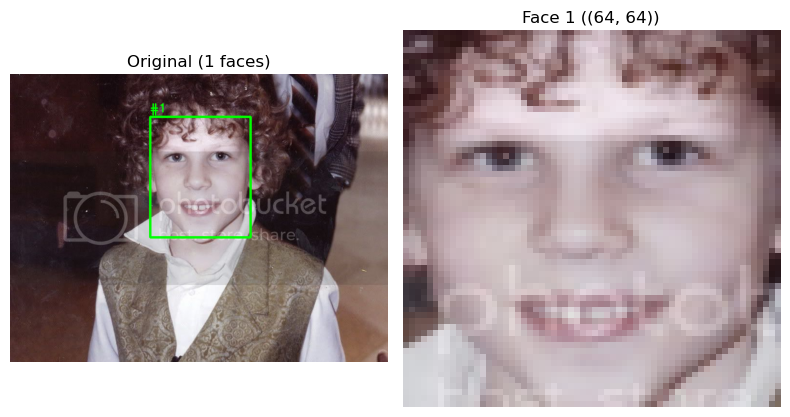

In [44]:
faces = extract_and_visualize_faces(test.iloc[31]['img'], face_detector)

In [43]:
predict_test_images(
    images=[test.iloc[31]['img']],
    model=clf,
    feature_extractor_func=extract_facenet_features_cpu,
    face_detector=face_detector
    )

/home/steph/miniconda3/envs/cv/lib/python3.11/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


([0], array([[0.07203848, 0.40036768, 0.07359778, 0.02782289, 0.42617318]]))

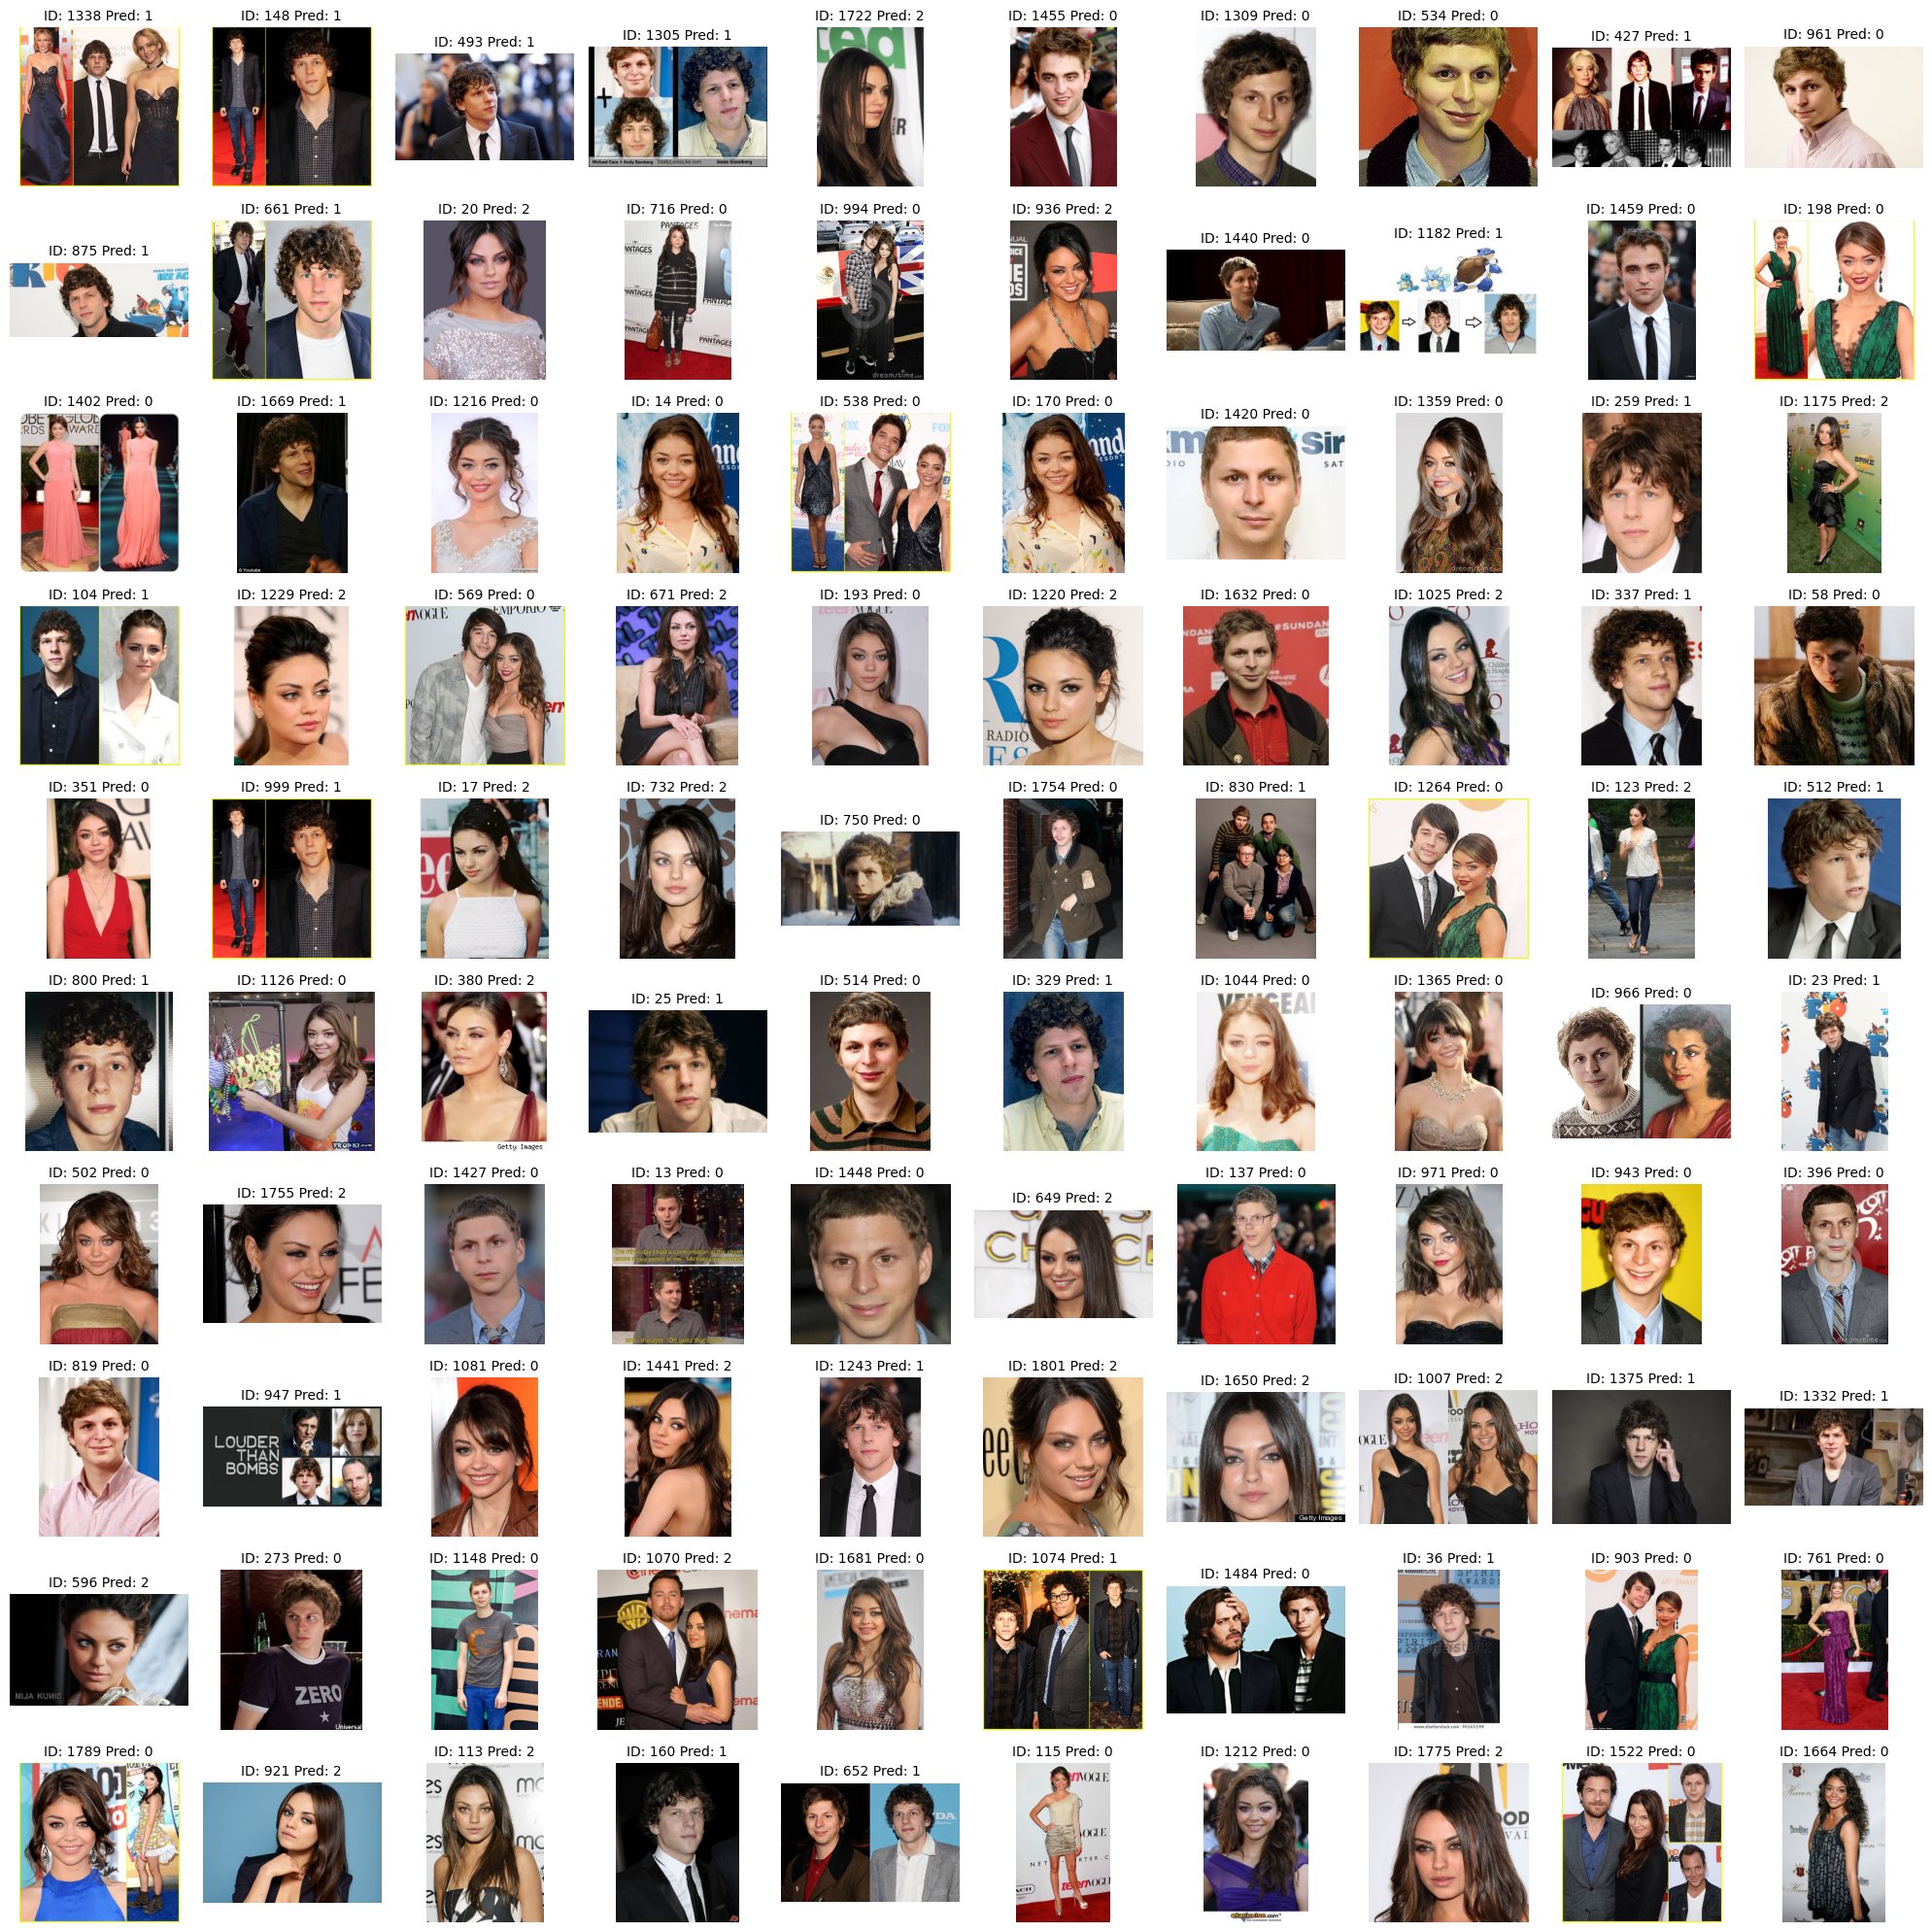

In [288]:
# 1. Load the labels back from your saved file
if final_test_predictions:
    labels = np.array(final_test_predictions)
else:
    submission_df = pd.read_csv('submission.csv')
    labels = submission_df['class'].values

# 2. Setup the plotting grid (10x10)
fig, axes = plt.subplots(10, 10, figsize=(20, 20))
axes = axes.flatten() # Flatten so we can iterate with a single index
check = set()

for i in range(100):
    rnd = random.randint(0, len(test) - 1) # Randomly sample an index to display
    while rnd in check: # Ensure we don't display the same image twice
        rnd = random.randint(0, len(test) - 1)
    check.add(rnd)
    # Display the image from your 'test' dataframe
    # Assuming 'img' column contains the pixel arrays
    axes[i].imshow(test.iloc[rnd]['img'])
    
    # Set the title using the 'class' we just extracted
    axes[i].set_title(f"ID: {rnd} Pred: {labels[rnd]}", fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [45]:
submission = test.copy().drop('img', axis=1)
submission['class'] = final_test_predictions
submission.to_csv('submission.csv')

print(f"Saved {len(submission)} predictions to submission.csv")
submission.head()

Saved 1816 predictions to submission.csv


,class
id,
0,1
1,0
2,0
3,0
4,1
